# 02. Random Forest History Sweep (h=0..10) & Kinematic Filtering — 200 Users

This notebook evaluates **Random Forest Regressor** across a comprehensive sweep of history depths:
$$\mathbf{h \in [0, 1, 2, 3, 4, 5, 7, 10]}$$

### Experimental Setup:
- **Dataset:** 5G NR 3.0 GHz 200-User Dataset (`99,589 samples`).
- **Unseen User Evaluation:** 160 Training Users vs. 40 Unseen Test Users.
- **Feature Modes:** Hybrid Set ($m(t)$ + $\Delta$ lags) & Absolute Lags Set.
- **Kinematic Filtering:** Raw RF Predictions vs. Forward Linear KF vs. Rauch-Tung-Striebel (RTS) Kalman Smoother.

In [1]:
import sys, os, time, warnings, json, math, datetime, glob
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from scipy.linalg import inv

NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR
for _ in range(10):
    if (PROJECT_ROOT / 'results' / 'grid_localization' / 'grid_25x25').exists():
        break
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / 'experiments' / '09_grid_localization' / 'src' / 'python'))

from pipelines.multi_user_200_pipeline import load_200_users, make_unseen_user_split
from pipelines.multi_user_pipeline_regression import _read_bs_position_3d, build_history_features, get_feature_cols

RUN_TIMESTAMP = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
OUT_DIR = PROJECT_ROOT / 'results' / 'notebook_experiments' / 'multi_user_poc' / f'rf_history_sweep_{RUN_TIMESTAMP}'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Output directory: {OUT_DIR}')

Output directory: D:\gilad\projects\Academy\CSI-Location\results\notebook_experiments\multi_user_poc\rf_history_sweep_2026-07-24_20-15-18


## Define Kinematic Forward Kalman Filter & RTS Backward Smoother

In [2]:
def run_kalman_and_rts(y_true, y_pred, delta_t_vec, process_noise_std=0.5, R_std=15.0):
    N = len(y_pred)
    if N == 0:
        return y_pred, y_pred
    
    H = np.zeros((3, 6))
    H[0, 0], H[1, 1], H[2, 2] = 1.0, 1.0, 1.0
    R = (R_std ** 2) * np.eye(3)
    
    x_pred = np.zeros((N, 6)); P_pred = np.zeros((N, 6, 6))
    x_filt = np.zeros((N, 6)); P_filt = np.zeros((N, 6, 6))
    
    x_filt[0, :3] = y_pred[0]
    P_filt[0] = np.eye(6) * 100.0
    x_pred[0], P_pred[0] = x_filt[0], P_filt[0]
    
    for t in range(1, N):
        dt = max(0.01, float(delta_t_vec[t]))
        F = np.eye(6); F[0, 3], F[1, 4], F[2, 5] = dt, dt, dt
        q = (process_noise_std ** 2)
        Q = np.diag([q*(dt**2), q*(dt**2), q*(dt**2), q, q, q])
        
        x_p = F @ x_filt[t-1]
        P_p = F @ P_filt[t-1] @ F.T + Q
        x_pred[t], P_pred[t] = x_p, P_p
        
        z_t = y_pred[t]
        y_k = z_t - H @ x_p
        S_k = H @ P_p @ H.T + R
        K_k = P_p @ H.T @ inv(S_k)
        
        x_filt[t] = x_p + K_k @ y_k
        P_filt[t] = (np.eye(6) - K_k @ H) @ P_p
        
    x_smooth = np.zeros((N, 6)); P_smooth = np.zeros((N, 6, 6))
    x_smooth[-1], P_smooth[-1] = x_filt[-1], P_filt[-1]
    
    for t in range(N - 2, -1, -1):
        dt = max(0.01, float(delta_t_vec[t+1]))
        F = np.eye(6); F[0, 3], F[1, 4], F[2, 5] = dt, dt, dt
        C_k = P_filt[t] @ F.T @ inv(P_pred[t+1])
        x_smooth[t] = x_filt[t] + C_k @ (x_smooth[t+1] - x_pred[t+1])
        P_smooth[t] = P_filt[t] + C_k @ (P_smooth[t+1] - P_pred[t+1]) @ C_k.T
        
    return x_filt[:, :3], x_smooth[:, :3]

## Load 200-User Dataset & Apply 4° AoA Noise

In [3]:
data_base = PROJECT_ROOT / 'results' / 'grid_localization' / 'grid_25x25'
dirs = sorted(list(data_base.glob('sim_data_200users_*')))
if not dirs:
    raise FileNotFoundError('No sim_data_200users_* dataset directories found!')
DATA_DIR = dirs[-1]
print(f'Loading 200-User dataset from: {DATA_DIR}')

df_raw = load_200_users(DATA_DIR)
print(f'Loaded {len(df_raw):,} records across {len(df_raw["user_id"].unique())} diverse mobile users.')

bs_pos = np.array(_read_bs_position_3d(DATA_DIR))
ue_xyz = np.column_stack([df_raw['x_pos'], df_raw['y_pos'], df_raw['ue_height']])
delta  = ue_xyz - bs_pos
df_raw['target_x'], df_raw['target_y'], df_raw['target_z'] = delta[:,0], delta[:,1], delta[:,2]

SEED = 42
AOA_NOISE_STD_DEG = 4.0
AOA_QUANT_STEP_DEG = 5.0
mask_ant = df_raw['n_antennas'] > 1
rng_noise = np.random.RandomState(SEED)
df_raw.loc[mask_ant, 'aoa_azimuth'] = df_raw.loc[mask_ant, 'aoa_azimuth'].values + (AOA_NOISE_STD_DEG * rng_noise.randn(mask_ant.sum())).astype(np.float32)
df_raw.loc[mask_ant, 'aoa_elevation'] = df_raw.loc[mask_ant, 'aoa_elevation'].values + (AOA_NOISE_STD_DEG * rng_noise.randn(mask_ant.sum())).astype(np.float32)
df_raw.loc[mask_ant, 'aoa_azimuth'] = np.round(df_raw.loc[mask_ant, 'aoa_azimuth'] / AOA_QUANT_STEP_DEG) * AOA_QUANT_STEP_DEG
df_raw.loc[mask_ant, 'aoa_elevation'] = np.round(df_raw.loc[mask_ant, 'aoa_elevation'] / AOA_QUANT_STEP_DEG) * AOA_QUANT_STEP_DEG
df_raw.loc[~mask_ant, ['aoa_azimuth', 'aoa_elevation']] = 0.0
print('Noise model applied.')

Loading 200-User dataset from: D:\gilad\projects\Academy\CSI-Location\results\grid_localization\grid_25x25\sim_data_200users_2026-07-24_18-09-51


Loaded 99,589 records across 200 diverse mobile users.
Noise model applied.


## Execute History Depth Sweep (h=0, 1, 2, 3, 4, 5, 7, 10)

In [4]:
H_LIST = [0, 1, 2, 3, 4, 5, 7, 10]
FEATURE_MODE = 'hybrid'
N_JOBS = 4
results = []
sample_user_trajectories = {}  # Store sample trajectory predictions for h=10

print('Starting Random Forest History Depth Sweep across h=0..10...')
print('='*75)

for h in H_LIST:
    mode = 'absolute' if h == 0 else FEATURE_MODE
    df_feat = build_history_features(df_raw, h=h, extra_cols=['device'], include_aoa=True, feature_mode=mode)
    feat_cols = get_feature_cols(h=h, extra_cols=['device'], include_aoa=True, feature_mode=mode)
    target_cols = ['target_x', 'target_y', 'target_z']
    df_feat[feat_cols] = df_feat[feat_cols].fillna(0.0)
    
    df_split, train_users, test_users = make_unseen_user_split(df_feat, train_ratio=0.80, seed=SEED)
    df_train = df_split[df_split['split']=='train'].reset_index(drop=True)
    df_test  = df_split[df_split['split']=='test'].reset_index(drop=True)
    
    X_tr, y_tr = df_train[feat_cols].values, df_train[target_cols].values
    X_te, y_te = df_test[feat_cols].values, df_test[target_cols].values
    
    t0 = time.time()
    rf = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=5, n_jobs=N_JOBS, random_state=SEED)
    rf.fit(X_tr, y_tr)
    t_fit = time.time() - t0
    
    preds_raw = rf.predict(X_te)
    df_test['pred_x'] = preds_raw[:, 0]
    df_test['pred_y'] = preds_raw[:, 1]
    df_test['pred_z'] = preds_raw[:, 2]
    
    raw_err = np.linalg.norm(preds_raw - y_te, axis=1)
    mae_raw = np.mean(raw_err)
    
    kf_preds = np.zeros_like(preds_raw)
    rts_preds = np.zeros_like(preds_raw)
    
    for uid in test_users:
        idx_u = df_test['user_id'] == uid
        udf = df_test[idx_u].sort_values('step_index')
        u_indices = udf.index.values
        
        y_u_true = udf[target_cols].values
        y_u_pred = udf[['pred_x', 'pred_y', 'pred_z']].values
        dt_u     = udf['delta_t'].values
        
        x_kf, x_rts = run_kalman_and_rts(y_u_true, y_u_pred, dt_u, process_noise_std=0.5, R_std=15.0)
        kf_preds[u_indices]  = x_kf
        rts_preds[u_indices] = x_rts
        
    mae_kf  = np.mean(np.linalg.norm(kf_preds - y_te, axis=1))
    mae_rts = np.mean(np.linalg.norm(rts_preds - y_te, axis=1))
    red_rts = ((mae_raw - mae_rts) / mae_raw) * 100.0
    
    if h == 10:
        target_uid = sorted(list(test_users))[0]
        idx_target = df_test['user_id'] == target_uid
        udf_target = df_test[idx_target].sort_values('step_index')
        u_t_indices = udf_target.index.values
        sample_user_trajectories = {
            'uid': target_uid,
            'gt': udf_target[target_cols].values,
            'raw': preds_raw[u_t_indices],
            'rts': rts_preds[u_t_indices]
        }
    
    results.append({
        'h': h,
        'features': len(feat_cols),
        'fit_time_s': t_fit,
        'mae_raw': mae_raw,
        'mae_kf': mae_kf,
        'mae_rts': mae_rts,
        'red_rts_pct': red_rts
    })
    
    print(f'  h={h:2d} ({len(feat_cols):2d} feats) -> Raw RF: {mae_raw:6.3f}m | Forward KF: {mae_kf:6.3f}m | RTS Smoother: {mae_rts:6.3f}m ({red_rts:+5.1f}%) | Time: {t_fit:4.1f}s')

Starting Random Forest History Depth Sweep across h=0..10...


  h= 0 ( 7 feats) -> Raw RF: 27.704m | Forward KF: 27.249m | RTS Smoother: 26.540m ( +4.2%) | Time:  5.0s


  h= 1 (11 feats) -> Raw RF: 26.607m | Forward KF: 26.801m | RTS Smoother: 25.848m ( +2.9%) | Time:  8.8s


  h= 2 (15 feats) -> Raw RF: 26.167m | Forward KF: 26.456m | RTS Smoother: 25.499m ( +2.6%) | Time: 12.9s


  h= 3 (19 feats) -> Raw RF: 26.093m | Forward KF: 26.445m | RTS Smoother: 25.476m ( +2.4%) | Time: 16.8s


  h= 4 (23 feats) -> Raw RF: 26.082m | Forward KF: 26.462m | RTS Smoother: 25.538m ( +2.1%) | Time: 20.4s


  h= 5 (27 feats) -> Raw RF: 25.945m | Forward KF: 26.277m | RTS Smoother: 25.365m ( +2.2%) | Time: 22.8s


  h= 7 (35 feats) -> Raw RF: 25.946m | Forward KF: 26.244m | RTS Smoother: 25.363m ( +2.3%) | Time: 33.5s


  h=10 (47 feats) -> Raw RF: 25.880m | Forward KF: 26.204m | RTS Smoother: 25.321m ( +2.2%) | Time: 38.5s


## Summary Benchmark Table (h=0..10)

In [5]:
df_res = pd.DataFrame(results)
print('\n' + '='*85)
print('=== RANDOM FOREST HISTORY SWEEP (h=0..10) & KALMAN SMOOTHING BENCHMARK ===')
print('='*85)
print(df_res.to_string(index=False, formatters={
    'h': lambda x: f'{x:2d}',
    'features': lambda x: f'{x:2d}',
    'fit_time_s': lambda x: f'{x:5.1f}s',
    'mae_raw': lambda x: f'{x:6.3f}m',
    'mae_kf': lambda x: f'{x:6.3f}m',
    'mae_rts': lambda x: f'{x:6.3f}m',
    'red_rts_pct': lambda x: f'{x:+5.1f}%'
}))
print('='*85)
df_res.to_csv(OUT_DIR / 'history_sweep_results.csv', index=False)


=== RANDOM FOREST HISTORY SWEEP (h=0..10) & KALMAN SMOOTHING BENCHMARK ===
 h features fit_time_s mae_raw  mae_kf mae_rts red_rts_pct
 0        7       5.0s 27.704m 27.249m 26.540m       +4.2%
 1       11       8.8s 26.607m 26.801m 25.848m       +2.9%
 2       15      12.9s 26.167m 26.456m 25.499m       +2.6%
 3       19      16.8s 26.093m 26.445m 25.476m       +2.4%
 4       23      20.4s 26.082m 26.462m 25.538m       +2.1%
 5       27      22.8s 25.945m 26.277m 25.365m       +2.2%
 7       35      33.5s 25.946m 26.244m 25.363m       +2.3%
10       47      38.5s 25.880m 26.204m 25.321m       +2.2%


## Visualization: 3D MAE vs. History Depth (h=0..10)

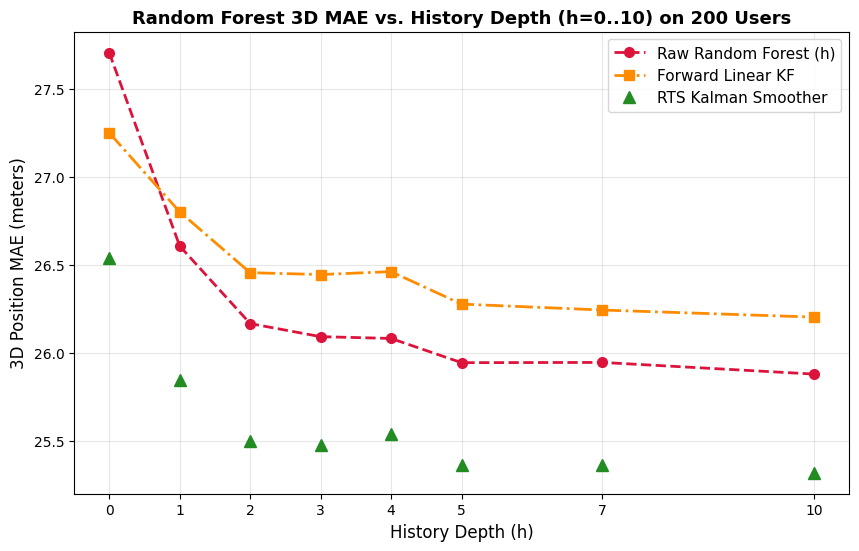

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(df_res['h'], df_res['mae_raw'], 'o--', color='crimson', lw=2, ms=7, label='Raw Random Forest (h)')
plt.plot(df_res['h'], df_res['mae_kf'], 's-.', color='darkorange', lw=2, ms=7, label='Forward Linear KF')
plt.plot(df_res['h'], df_res['mae_rts'], '^', color='forestgreen', lw=2.5, ms=8, label='RTS Kalman Smoother')
plt.xlabel('History Depth (h)', fontsize=12)
plt.ylabel('3D Position MAE (meters)', fontsize=12)
plt.title('Random Forest 3D MAE vs. History Depth (h=0..10) on 200 Users', fontsize=13, fontweight='bold')
plt.xticks(H_LIST)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.savefig(OUT_DIR / 'rf_history_sweep_mae.png', dpi=150, bbox_inches='tight')
plt.show()

## Trajectory Tracking Plot: Ground Truth vs. Predictions

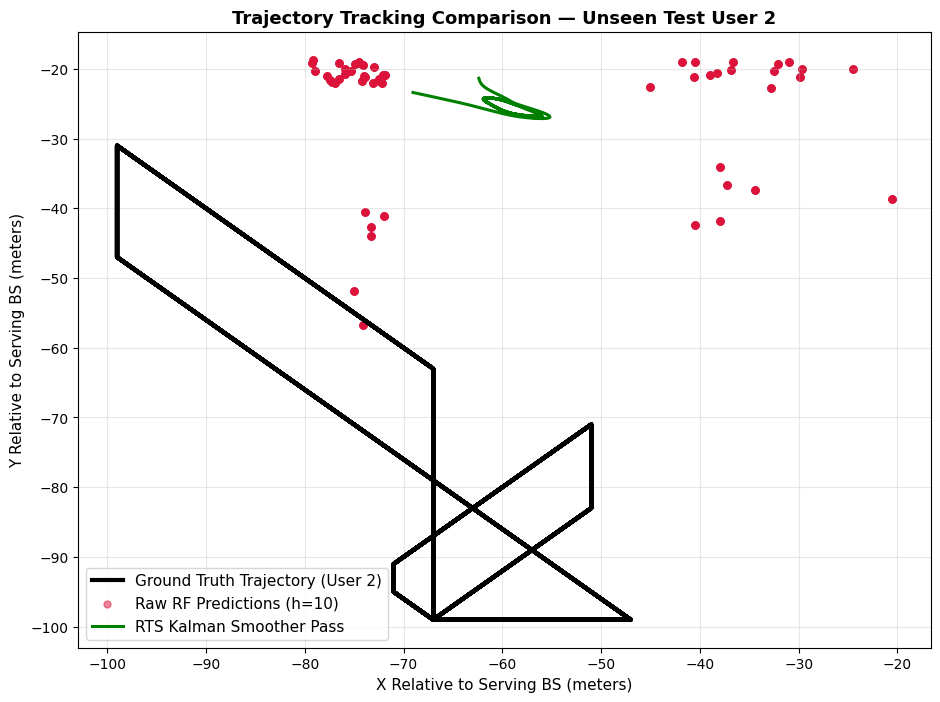

In [7]:
uid = sample_user_trajectories['uid']
gt  = sample_user_trajectories['gt']
raw = sample_user_trajectories['raw']
rts = sample_user_trajectories['rts']

plt.figure(figsize=(11, 8))
plt.plot(gt[:, 0], gt[:, 1], 'k-', lw=3.0, label=f'Ground Truth Trajectory (User {uid})')
plt.scatter(raw[:, 0], raw[:, 1], color='crimson', alpha=0.5, s=25, label='Raw RF Predictions (h=10)')
plt.plot(rts[:, 0], rts[:, 1], 'g-', lw=2.2, label='RTS Kalman Smoother Pass')
plt.xlabel('X Relative to Serving BS (meters)', fontsize=11)
plt.ylabel('Y Relative to Serving BS (meters)', fontsize=11)
plt.title(f'Trajectory Tracking Comparison — Unseen Test User {uid}', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig(OUT_DIR / 'rf_trajectory_tracking.png', dpi=150, bbox_inches='tight')
plt.show()